In [2]:
print("hello world")

hello world


In [3]:
import tensorflow as tf

In [13]:
import matplotlib.pyplot as plt

In [17]:
import os
print("Current Dir", os.getcwd())
curr_dir = os.getcwd()
train_path = os.path.join(curr_dir, "datasets", "train")
test_path = os.path.join(curr_dir, "datasets", "test")
valid_path = os.path.join(curr_dir, "datasets", "valid")
print(train_path)

Current Dir d:\AICTE_intership\project
d:\AICTE_intership\project\datasets\train


In [20]:
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='categorical',
    color_mode='rgb',
    image_size=(128,128 ),
    shuffle=True,
    interpolation='bilinear',
)

Found 900 files belonging to 3 classes.


In [21]:
training_set.class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [30]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels='inferred',
    label_mode='categorical',
    color_mode='rgb',
    image_size=(128,128 ),
    shuffle=True,
    interpolation='bilinear',
)

Found 300 files belonging to 3 classes.


In [25]:
cnn = tf.keras.models.Sequential()
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3,padding= 'same',activation='relu', input_shape=[128, 128, 3]))
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3,padding= 'same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3,padding= 'same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=256, kernel_size=3,padding= 'same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256, kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=512, kernel_size=3,padding= 'same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512, kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Dropout(0.25))

cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(units=1500, activation='relu'))
cnn.add(tf.keras.layers.Dropout(0.4))

cnn.add(tf.keras.layers.Dense(units=3, activation='softmax'))

In [26]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [31]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         4,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,790,227 (29.72 MB)

 Trainable params: 7,790,227 (29.72 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
training_history = cnn.fit(x=training_set, validation_data=validation_set, epochs=10)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 602ms/step - accuracy: 0.8295 - loss: 0.4391 - val_accuracy: 0.9400 - val_loss: 0.2105
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 714ms/step - accuracy: 0.9200 - loss: 0.2412 - val_accuracy: 0.9633 - val_loss: 0.1617
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 717ms/step - accuracy: 0.9292 - loss: 0.1960 - val_accuracy: 0.9767 - val_loss: 0.1036
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 731ms/step - accuracy: 0.9748 - loss: 0.1101 - val_accuracy: 0.9600 - val_loss: 0.0990
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 892ms/step - accuracy: 0.9697 - loss: 0.1140 - val_accuracy: 0.9733 - val_loss: 0.0740
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9821 - loss: 0.0787 - val_accuracy: 0.8967 - val_loss: 0.2045
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9172 - loss: 0.1587 - val_accuracy: 0.9833 - val_loss: 0.0722
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 900ms/step - accuracy: 0.9462 - loss: 0.1198 - val_accuracy: 0.9900

In [35]:
train_loss, train_acc = cnn.evaluate(training_set)
print('training accuracy :', train_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.9929 - loss: 0.0252
training accuracy : 0.9933333396911621


In [36]:
val_loss, val_acc = cnn.evaluate(validation_set)
print('validation accuracy :', val_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.9915 - loss: 0.0269
validation accuracy : 0.9933333396911621


In [37]:
cnn.save('trained_plant_disease_model.keras')

In [38]:
training_history.history

{'accuracy': [0.8199999928474426,
  0.9200000166893005,
  0.9433333277702332,
  0.9800000190734863,
  0.9633333086967468,
  0.9666666388511658,
  0.9399999976158142,
  0.9599999785423279,
  0.9666666388511658,
  0.9833333492279053],
 'loss': [0.4307368993759155,
  0.21963800489902496,
  0.1710578203201294,
  0.11104601621627808,
  0.13078518211841583,
  0.11562678217887878,
  0.13085247576236725,
  0.09777339547872543,
  0.0734926387667656,
  0.04860115051269531],
 'val_accuracy': [0.9399999976158142,
  0.9633333086967468,
  0.9766666889190674,
  0.9599999785423279,
  0.9733333587646484,
  0.8966666460037231,
  0.9833333492279053,
  0.9900000095367432,
  1.0,
  0.9933333396911621],
 'val_loss': [0.21051125228405,
  0.16169196367263794,
  0.10362852364778519,
  0.09898757189512253,
  0.07403019815683365,
  0.20451021194458008,
  0.07215151190757751,
  0.04200739040970802,
  0.02288087271153927,
  0.026590829715132713]}

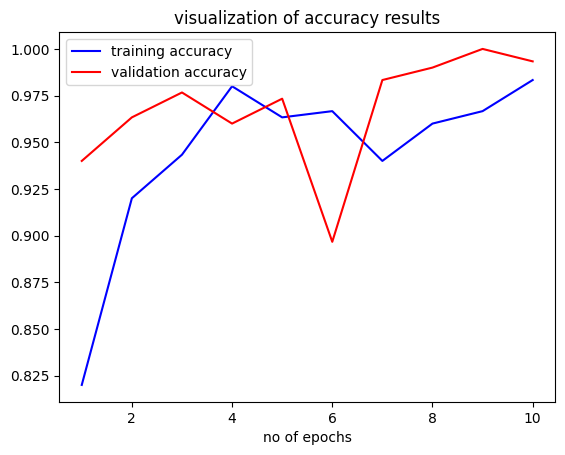

In [39]:
epochs = [i for i in range(1,11)]
plt.plot(epochs, training_history.history['accuracy'],color = 'blue', label = 'training accuracy')
plt.plot(epochs, training_history.history['val_accuracy'],color = 'red', label = 'validation accuracy')
plt.xlabel('no of epochs')
plt.title('visualization of accuracy results')
plt.legend()
plt.show()

In [41]:
!pip install streamlit


[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: C:\Users\Akshay\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
!pip install pandas



[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: C:\Users\Akshay\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: streamlit in c:\users\akshay\appdata\local\packages\pythonsoftwarefoundation.python.3.11_qbz5n2kfra8p0\localcache\local-packages\python311\site-packages (1.42.0)




[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: C:\Users\Akshay\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
